<a href="https://colab.research.google.com/github/LeLucasB12/Data-Analysis-Challenge/blob/main/dasa_2p08_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team 15 DASA-2P08 Data Challenge
Lucas Batista (lb20ws@brocku.ca) <br>
Kristopher Gall (kg21aq@brocku.ca) <br>



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NOTE: throughout the code we use '\t' and '\n' to align text in print
# statements with tabs.

# NOTE: throughout the code we use the suffix :.#f on numbers to round them
#       inline to # decimal places.

# Introduction to Data Set

Our data set is sports data that has been gathered about games between two teams over a period of time for 6 sports teams, Teams A-F.

The data has the following dimensions:
- game_id (int): A unique identifier for the game played
- team (str): First team playing
- opponent (str): Second team playing
- home_game (bool): if the game is a Home game for the first team
- points_scored (int): how many points were scored by the first team
- points_allowed (int): how many points were scored by the second team
- attendance (int): how many people were in attendance at the game
- season: (str) if the season was regular or playoff
  - options: Regular, Playoff
- day_of_week (str): which day of the week the game was played on
  - options: Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunday
- weather (str): weather during game
  - options: Indoor, Cloudy, Clear
- won (bool): if the first team won the game


In [ ]:
# Loading data and looking at it
data = pd.read_csv('team15_sports.csv')
data

,game_id,team,opponent,home_game,points_scored,points_allowed,attendance,season,day_of_week,weather,won
0,1,Team D,Team A,True,77,72,15446.0,Regular,Saturday,Indoor,True
1,2,Team F,Team F,True,84,59,13078.0,Regular,Tuesday,Indoor,True
2,3,Team F,Team C,True,77,74,16317.0,Regular,Wednesday,Cloudy,True
3,4,Team E,Team C,False,87,73,NaN,Regular,Saturday,Clear,True
4,5,Team C,Team A,True,95,82,18230.0,Regular,Monday,Cloudy,True
...,...,...,...,...,...,...,...,...,...,...,...
495,496,Team D,Team C,False,89,85,11278.0,Regular,Tuesday,Cloudy,True
496,497,Team C,Team B,True,103,99,13666.0,Regular,Thursday,Cloudy,True
497,498,Team A,Team B,False,92,86,12413.0,Playoffs,Monday,Clear,True
498,499,Team E,Team E,False,86,81,20143.0,Regular,Thursday,Clear,True


# Data Cleaning

First we check for columns that have null data.

To do this we use the isna() function to check if cells are NaN and then we take the sum to count them per column.

In [ ]:
# Counting NaN values per column
data.isna().sum()

,0
game_id,0
team,0
opponent,0
home_game,0
points_scored,0
points_allowed,0
attendance,30
season,0
day_of_week,0
weather,20


The weather column is not used in any of the questions so we will drop it. Attendance we need to interpolate data. We use axis 1 to drop a column.

We all take the attendance data and replace the NaN values with the average attendance. This could possibly skew the data towards the overall mean but since there are 30 missing data points, it represents ~6% of the entire dataset which is significant.

In [ ]:
# Dropping weather
data = data.drop('weather', axis= 1)

# Replacing with average attendance
data['attendance'] = data['attendance'].fillna(value= data['attendance'].mean())
data.isna().sum()

,0
game_id,0
team,0
opponent,0
home_game,0
points_scored,0
points_allowed,0
attendance,0
season,0
day_of_week,0
won,0


Now we are going to check if all of the data types are unique for each of the columns.

To do this we are mapping the type() function to all cells of the data frame and then counting the unique types per column.

In [ ]:
# Checking how many datatypes per column
data.map(type).nunique()

,0
game_id,1
team,1
opponent,1
home_game,1
points_scored,1
points_allowed,1
attendance,1
season,1
day_of_week,1
won,1


After cleaning we have done the following:

Missing Value Handling:
- We are replacing the missing values in the Attendance column with the mean value since it represents roughly ~6% of the dataset.
- The weather column is being removed because it is not needed to answer any of the questions.

Data Type Corrections:
- There are no data type issues with the remaining columns.

Inconsistancy Resolution:
- The data appears to be consistent after the first two steps.

Invalid Data Removal:
- We dropped the weather as it was not needed to answer any of our questions and it had data type issues and missing data.

# Question 1
What is the win rate for home games vs away games?

## Solution
The data set has no overepresentation on away or home games. They are almost fully balanced within a percent of difference.

The thought process was to compare home wins and away wins to the total wins of the season. The percentage can be acquired following the ratio calculations. Based on that we can conclude that away teams had a higher win rate.

Analysis results:

1. Playoffs games have a higher count + higher win rate margin
Away (Playoffs): 42 games, 64.3% win rate
Home (Playoffs): 26 games, 38.5% win rate

2. Away games had a better scoring margin

Overall averages:

Away avg margin: +3.19
Home avg margin: +1.75

That comes from:

Away scored a bit more: 84.61 vs 83.71

Away allowed a bit less: 81.42 vs 81.96


Home win:49.45054945054945%
Away win: 50.54945054945055%


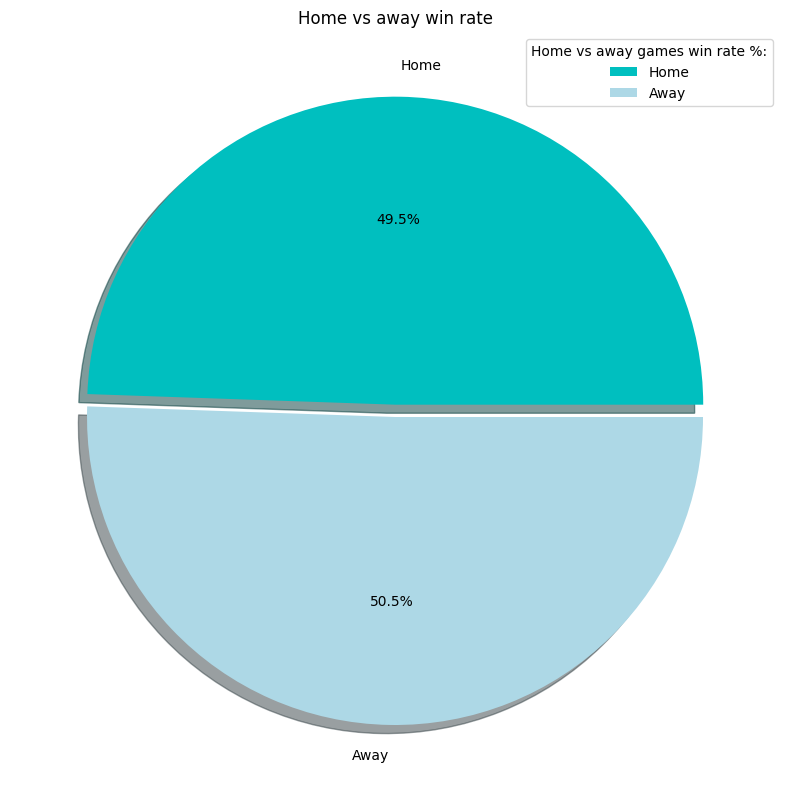

In [ ]:
# Selecting home wins and away wins
home_wins = data[(data["home_game"] == True) & (data["won"] == True)].shape[0]
away_wins = data[(data["home_game"] == False) & (data["won"] == True)].shape[0]

# Sum of home and away wins
total_wins = home_wins + away_wins

# Calculation of percentages
home_pct = (home_wins / total_wins) * 100
away_pct = (away_wins / total_wins) * 100

# Output of percentages
print(f"Home win:{home_pct}%")
print(f"Away win: {away_pct}%")

myexplode = [0.04, 0]
mycolors = ["c", "lightblue"]
mylabels = ["Home", "Away"]

fig = plt.figure(figsize=(10,10))
plt.pie([home_pct, away_pct], labels= mylabels, explode = myexplode, shadow = True, colors = mycolors, autopct='%1.1f%%')
plt.title("Home vs away win rate")
plt.legend(title = "Home vs away games win rate %:")
plt.show()

1. Rows are selected where home games are True and where "Won" column has the value "TRUE"
2. Rows are selected where home games are False (away games) and where the "Won"column has the value "TRUE"
3. Sum of total home wins and away wins occurs into total_wins
4. The calculation of the ration between (home wins / total wins) * 100 occurs (win rate formula)
5. The calculation of the ration between (away wins / total wins) * 100 occurs (win rate formula)
6. The output of home and away wins percentage is printed



# Question 2
Which team has the best overall record?

## Solution
First we grab the data where the teams won using a boolean selector.

Next we use 2 dictonary comprehensions to group the team overall data
and the team win data.

We use the following formula:
$$
\text{Win Rate} = \frac{\text{# of Wins}}{\text{# of Games Played}}
$$
to create a third dictionary comprehension that stores the win rates of
each team.

Lastly we output the data for display.

In [ ]:
# Storing win data
win_data = data[data['won'] == True]

# Dictionary comprehensions to hold team data and win rates
team_names = ['Team A', 'Team B', 'Team C', 'Team D', 'Team E', 'Team F']
team_data = {team: data[data['team'] == team] for team in team_names}
team_win_data = {team: win_data[win_data['team'] == team] for team in team_names}
win_percentages = {team: team_win_data[team].shape[0] / team_data[team].shape[0] for team in team_names}

# Terminal Output
print(f'=== Question 2 Summary ===\n')
print(f'Win Records:\n')
for team in team_names:
  print(f"{team}: {(win_percentages[team] * 100):.2f}%")

=== Question 2 Summary ===

Win Records:

Team A: 65.00%
Team B: 59.46%
Team C: 57.14%
Team D: 51.02%
Team E: 48.78%
Team F: 48.31%


Therefore, Team A had the best win rate.



# Question 3
How does attendance correlate with team performance?

## Solution
First, we take a subset of the numeric indicators of success, namely the following metrics: <br>
- attendance - number of people who attended the game <br>
- points_scored - number of points scored per game <br>
- points_allowed - number of points that were allowed per game <br>
- won - number of games won <br>

Next, we create a correlation matrix to find the correlation between each of these variables and attendence and output it for the user to see.

We note that the default correlation coefficient in Pandas is the Pearson Coefficient given by:
$$
\rho_{x,y} = \frac{\text{cov(x,y)}}{\sigma_x\sigma_y}
$$
where: <br>
$\text{cov}(x,y)$ is the covariance of $x,y$
<br>
$\sigma_k$ is the standard deviation of $k$

Finally, we create a scatter plot matrix to see if the data shows what we expect given these very flat correlations.







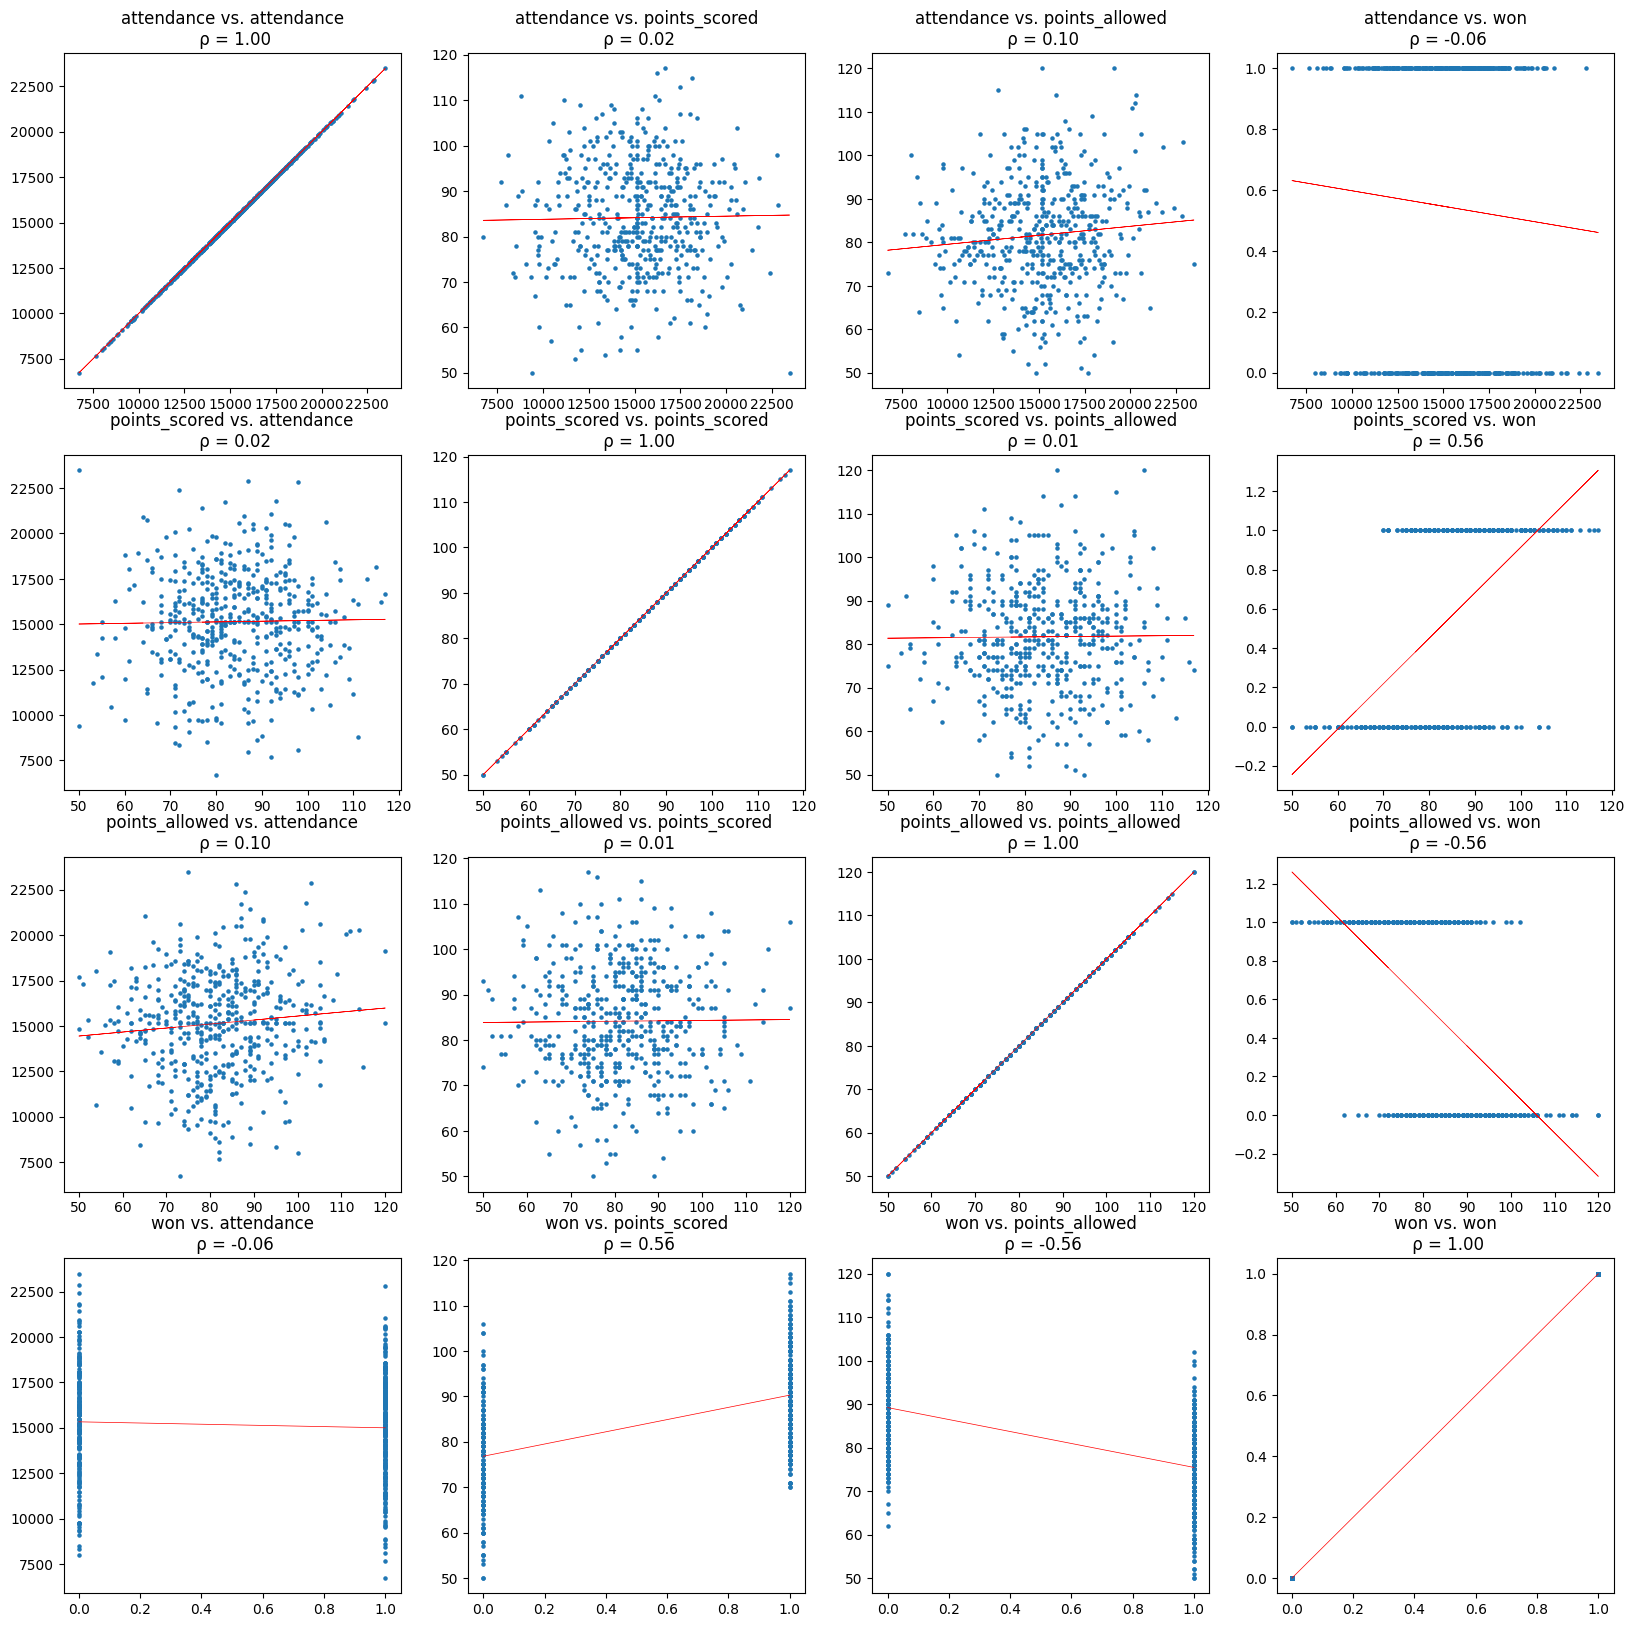

In [ ]:
# Creating subset with metrics we want
subset_titles = ['attendance', 'points_scored', 'points_allowed', 'won']
subset = data[subset_titles]

# Computing correlation and turning into a 2D array to get values easier
correlation = subset.corr()
correlation = correlation.to_numpy()

# Creating a correlation plot matrix
fig, axs = plt.subplots(nrows= 4, ncols= 4, figsize=(20,20))
for i in range(0,4):
  for j in range(0,4):

    x = subset[subset_titles[i]]
    y = subset[subset_titles[j]]

    # Making a line of best fit
    m, b = np.polyfit(x, y, 1)
    axs[i][j].plot(
        x, m*x+b,
        color= 'red', linestyle='-', linewidth= 0.5
        )

    # Making scattter plot
    axs[i][j].scatter(
        x, y,
        s= 5, # dot scale
        label= f"ρ = {correlation[i][j]}" # labelling subplot
        )

    # Adding title and text box
    axs[i][j].set_title(
        f"{subset_titles[i]} vs. {subset_titles[j]}\n ρ = {correlation[i][j]:.2f}"
        )

# Showing the matrix
plt.show()

As we can see there is very low correlation between attendance and the other metrics resulting in very loose data in the correlation plot matrix. We do not see any distinct shapes among the numeric variables. The line is just to indicate the correlation for visualization purposes.

Wins has very little correlation but shows a clustering into two sets, which is to be expected since the data is boolean which essentially is two classifications.

Points Allowed is the highest correlated metric with ρ = 0.10 which is extremely poor.

We can conclude there is almost no correlation between attendance and team performance.

# Question 4
Do teams score more points on specific days of the week?

# Solution
First we generate the daily data from the original data set and store it in a dictionary.

We calculated the daily means with a list comprehension.

Next we output these for the user to see.

After this we calculate a confidence interval over the means to see if there are any statistically significant outliers.

Since no significance threshold was given we will calculate the confidence intervals for $\alpha \in \{0.10, 0.05, 0.01\}$ or in other words, the 90%, 95% and 99% confidence intervals for the mean.

Now we calculate the interval using:
$$
\bar{x} \pm Z_{\alpha/2}\frac{\sigma}{\sqrt{n}}
$$
since we assume that this is the entire population of games and the population tends towards normal by the Central Limit Theorem since number of games $n > 30$.

Lastly we plot all of this onto a chart showing:
- The daily means in blue
- The total mean in red
- The confidence interval as an orange region

=== Question 4 Summary ===

Averages: 
  Monday: 85.6623
  Tuesday: 83.3514
  Wednesday: 82.9077
  Thursday: 85.0000
  Friday: 83.8684
  Saturday: 83.8312
  Sunday: 84.4571
 Total Average: 84.1580


Confidence Intervals: 
  90.0% Confidence Interval for Overall Mean: (83.27430078437786, 85.04169921562215)
  95.0% Confidence Interval for Overall Mean: (83.10508178564172, 85.21091821435829)
  99.0% Confidence Interval for Overall Mean: (82.77470183572827, 85.54129816427174)


Plot:


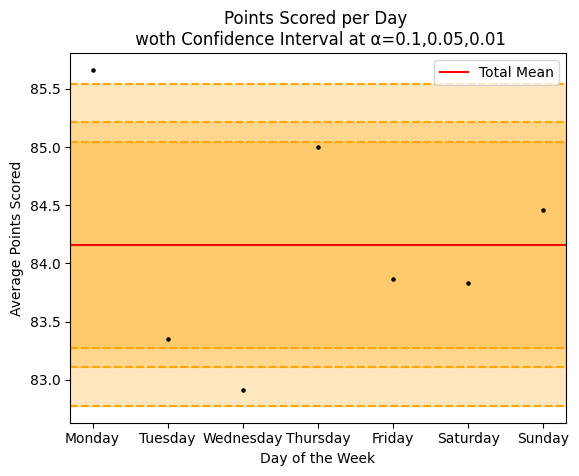

In [ ]:
# List of days to generate the data
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_data = {day: data[data['day_of_week'] == day] for day in days}

# Calculating means and cleaning them up
day_means = {day : float(day_data[day]['points_scored'].mean()) for day in days}

# Getting summary statistics for visualization
total_count = data['points_scored'].count()
total_average = data['points_scored'].mean()
total_variance = data['points_scored'].var()

# Calculating Confidence Intervals
# NOTE: We use an anonymous function for
#       the confidence inteval to keep the code clean
alphas = [0.10, 0.05, 0.01]
z_scores = [1.645, 1.96, 2.575] # Common approximations for given alphas
standard_error = np.sqrt(total_variance / total_count)
ci = lambda x,z: (float(x - z * standard_error), float(x + z * standard_error))
intervals = {alpha: ci(total_average, z) for alpha, z in zip(alphas, z_scores)}

# Visualization
# Adding Confidence Interval Lines
for alpha in alphas:
  for bound in intervals[alpha]:
    plt.axline(
        xy1=(0,bound),
        slope = 0,
        color = 'orange', ls='dashed'
        )

# Filling in Confidence Intevals
for alpha in alphas:
  plt.axhspan(intervals[alpha][0], intervals[alpha][1],
              color='orange', alpha=0.25)

# Adding mean line
mean_line = plt.axline(xy1 = (0, total_average),
           slope = 0,
           color = 'r'
           )

# Making Scatter Plot
plt.scatter(
    x= days,
    y= day_means.values(),
    marker= 'o', color='black', s=5
)
# Adding title, labels and legends
plt.title("Points Scored per Day \n woth Confidence Interval at α=0.1,0.05,0.01")
plt.xlabel("Day of the Week")
plt.ylabel("Average Points Scored")
plt.legend(
    [mean_line, intervals[0.05]],
    ['Total Mean']
)

# Terminal Output
print("=== Question 4 Summary ===")
print("")
# Printing averages
print("Averages: ")
for day, mean in zip(days , day_means):
  print(f"  {day}: {day_means[day]:.4f}")
print(f" Total Average: {total_average:.4f}")
print("\n")
# Printing Confident Intervals
print("Confidence Intervals: ")
for alpha in alphas:
  print(f"  {(1 - alpha) * 100}% Confidence Interval for Overall Mean: {intervals[alpha]}")
print("\n")
# Showing plot
print("Plot:")
plt.show()

We see that all of the days except two fall inside the 95% Confidence Interval.

We can conclude from the following:
1. Statistically significantly more points are scored on Monday with a 99% confidence level.
2. Statistically significantly less points are scored on Wednesday with a 95% confidence level.

# Question 5
What is the average point differential in wins vs. losses?


## Solution
First we recall that a point differential as the following formula:
$$
 \Delta P = P_{scored} - P_{allowed}
$$
where the sign of the differential indicated if it is for or against your team and the magnitude of the differential indicates how many points difference.

We calculate this for the two classes: Games won and games lost.


  Point differential mean in wins: 14.816849816849818
  Point differential mean in loss: -12.396475770925111



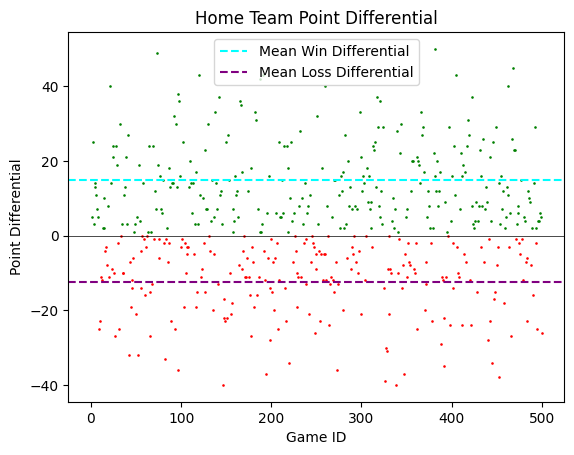

In [ ]:
# Creating differential with a pandas selector
differential_data = data.copy()
differential_data['points_differential'] = differential_data['points_scored'] - differential_data['points_allowed']

# Calculating means
win_mean = differential_data[differential_data['won'] == True]['points_differential'].mean()
loss_mean = differential_data[differential_data['won'] == False]['points_differential'].mean()

# Outputting the data
print(f"""
  Point differential mean in wins: {win_mean}
  Point differential mean in loss: {loss_mean}
""")

# Plotting the mean lines for visualization
win_mean_line = plt.axline((0, win_mean), slope = 0,
                      color='cyan', ls= 'dashed')
loss_mean_line = plt.axline((0, loss_mean), slope = 0,
                       color='purple', ls= 'dashed')
zero_line = plt.axline((0,0), slope = 0,
                       color= 'black', lw=0.5)

# Plotting the winning differentials in green
win_plot = plt.scatter(
    x= differential_data[differential_data['won'] == True]['game_id'],
    y= differential_data[differential_data['won'] == True]['points_differential'],
    color='green',
    s = 0.75
    )
# Plotting the losing differentials in red
loss_plot = plt.scatter(
    x= differential_data[differential_data['won'] == False]['game_id'],
    y= differential_data[differential_data['won'] == False]['points_differential'],
    color='red',
    s = 0.75
    )

# Adding title, labels and legend
plt.title('Home Team Point Differential')
plt.xlabel('Game ID')
plt.ylabel('Point Differential')
plt.legend(
    [win_mean_line, loss_mean_line],
    ['Mean Win Differential', 'Mean Loss Differential']
)
plt.show()

This data makes sense since you would expect the differential to be positive when you win and negative when you lose.

This is reinforced because the data is evenly distributed along x=0. This makes sense because if you have a negative differential you necessarily
 lost and if you have a positive differential you necessarily
 won. We can also tell the calculate was right since we see no green or red dots on the incorrect side.

It is of note that there are some red dots on the 0 line. This is because since we do not known what sport this is, we cannot tell how they handle ties. In most sports we are familiar with a tie is a seperate classification from a tie, so we will treat it as not a win since the column denotes specifically wins.

 Below we show the tied games (differential of 0) in case it is of note to the user:


In [ ]:
differential_data[abs(differential_data['points_differential']) < 1]

,game_id,team,opponent,home_game,points_scored,points_allowed,attendance,season,day_of_week,won,points_differential
32,33,Team D,Team A,True,72,72,13074.0,Regular,Wednesday,False,0
56,57,Team D,Team D,False,82,82,17305.0,Regular,Wednesday,False,0
61,62,Team F,Team C,False,72,72,15689.0,Regular,Friday,False,0
130,131,Team D,Team C,True,92,92,15215.0,Regular,Saturday,False,0
169,170,Team E,Team F,False,82,82,14973.0,Regular,Tuesday,False,0
225,226,Team E,Team B,False,92,92,12451.0,Regular,Thursday,False,0
244,245,Team E,Team B,True,74,74,9756.0,Regular,Sunday,False,0
262,263,Team A,Team A,False,78,78,12976.0,Playoffs,Monday,False,0
291,292,Team D,Team B,True,62,62,17161.0,Playoffs,Wednesday,False,0
304,305,Team E,Team F,False,81,81,15883.0,Playoffs,Sunday,False,0


# Question 6
How do playoff games differ from the regular season games?

## Solution
The thought process was to generate a direct comparrison between playoff and regular games. The logic was to calculate the mean of every significant data column and compare it as a summary breakdown. We found that overall all categories were higher than regular season games, and the only exception is the win rate compared to regular games. The conclusion is that playoff games have a higher rate of competition between teams due to the losing team disqualified from proceeding, and resulting in higher average points scored, average attendance, and decrease in win rate.

--- Playoff Games ---
Average points scored: 84.63
Average points allowed: 82.90
Win rate: 54.41%
Average attendance: 15124.08

--- Regular Season Games ---
Average points scored: 84.08
Average points allowed: 81.51
Win rate: 54.63%
Average attendance: 15150.83


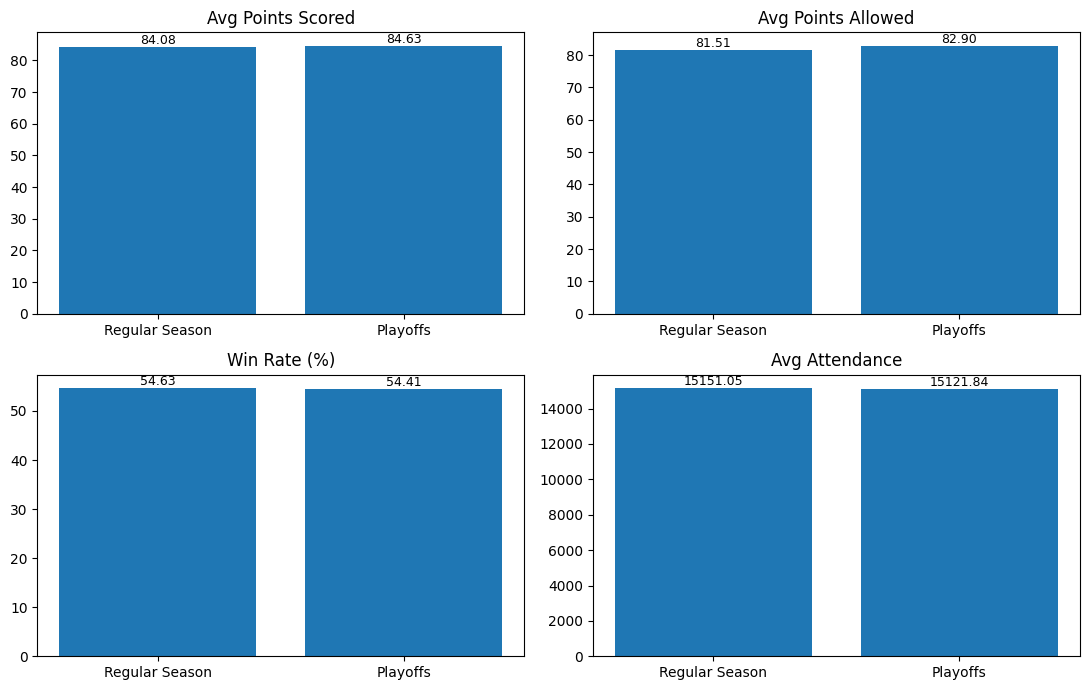

In [ ]:
# Selecting playoffs and regular season games
playoffs_data = data[data['season'] == 'Playoffs']
regular_season_data = data[data['season'] == 'Regular']

# Printing mean of key values for playoff games
print("--- Playoff Games ---")
print(f"Average points scored: {playoffs_data['points_scored'].mean():.2f}")
print(f"Average points allowed: {playoffs_data['points_allowed'].mean():.2f}")
print(f"Win rate: {playoffs_data['won'].mean() * 100:.2f}%")
print(f"Average attendance: {playoffs_data['attendance'].mean():.2f}")

# Printing mean of key values for regular games
print("\n--- Regular Season Games ---")
print(f"Average points scored: {regular_season_data['points_scored'].mean():.2f}")
print(f"Average points allowed: {regular_season_data['points_allowed'].mean():.2f}")
print(f"Win rate: {regular_season_data['won'].mean() * 100:.2f}%")
print(f"Average attendance: {regular_season_data['attendance'].mean():.2f}")

# Data from my output
metrics = ["Avg Points Scored", "Avg Points Allowed", "Win Rate (%)", "Avg Attendance"]
regular = [84.08, 81.51, 54.63, 15151.05]
playoffs = [84.63, 82.90, 54.41, 15121.84]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.bar(["Regular Season", "Playoffs"], [regular[i], playoffs[i]])
    ax.set_title(metrics[i])

    # Value labels
    ax.text(0, regular[i], f"{regular[i]:.2f}", ha="center", va="bottom", fontsize=9)
    ax.text(1, playoffs[i], f"{playoffs[i]:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

1. The selection of "Playoffs" values are filtered from "season" column
2. The selection of "Regular" values are gathered from "season" column
3. The mean is calculated for "Playoffs" from "points_scored" (average points scored) and displayed
4. The mean is calculated for "Playoffs" from "points_allowed" (average poins allowed) and displayed
5. The mean is calculated for "Playoffs" from "won" (win rate) and displayed
6. The mean is calculated for "Playoffs" from "attendance" (average attendance) and displayed
7. The mean is calculated for "Regular" from "points_scored" (average points scored) and displayed
8. The mean is calculated for "Regular" from "points_allowed" (average poins allowed) and displayed
9. The mean is calculated for "Regular" from "won" (win rate) and displayed
10. The mean is calculated for "Regular" from "attendance" (average attendance) and displayed


# Diagnostics
This section is used to check assumptions about the data.

## QQ-Plots
We assume our data should be normally distributed due to the Central Limit Theorem, but let's check anyway to be safe.

We generate QQ plots for the numeric data we used to see if they fall on the QQ line.


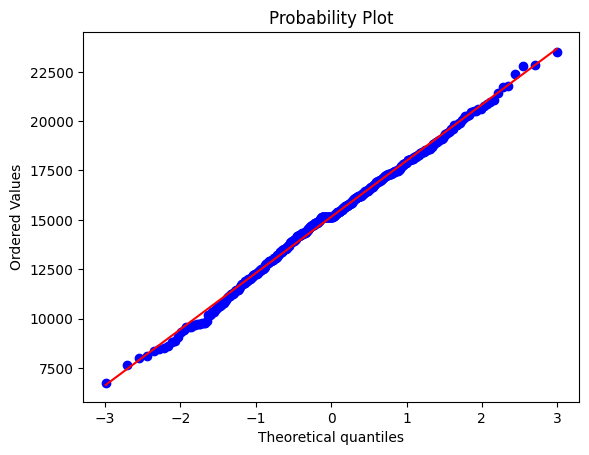

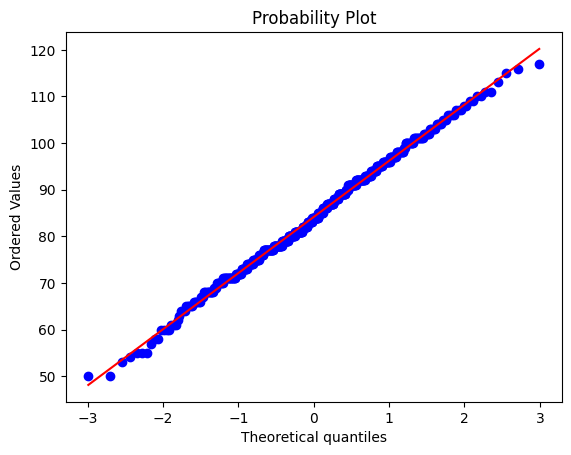

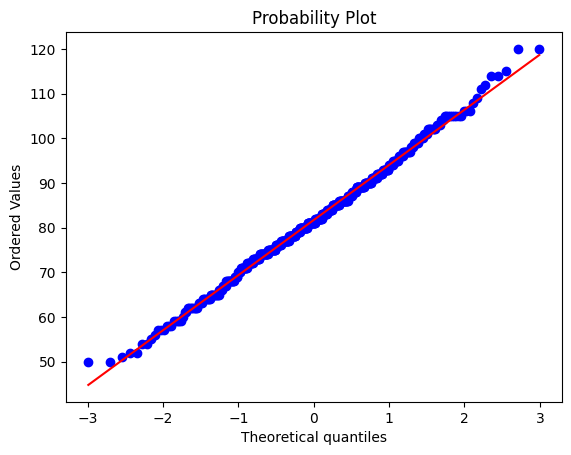

In [ ]:
import scipy.stats as stats

metric_titles = ['attendance', 'points_scored', 'points_allowed']

for title in metric_titles:
  stats.probplot(data[title], dist="norm", plot= plt)
  plt.show()

All the used parameters fall within acceptible bounds so we assume all of our data is normal.